# LAB 2 — Modelagem de Dados para Analytics

**Disciplina** Engenharia de Dados para IA

**Aula** 2 — Organização e Manuseio de Dados Relacionais

**Duração do Lab** ~1h30 (em aula)

**Entrega** Leitura do Diagrama ER + leitura do Star Schema + análise de 5 perguntas de negócio + justificativas

**Scripts de apoio** `lodlog_modelo_dados_v3.sql` e `lodlog_lab3_seed_v3`

1. O modelo operacional `lodlog_op` já vem **normalizado em 3FN**: cada informação é guardada uma única vez (os dados do cliente ficam só em `cliente`, os do veículo só em `veiculo` etc.).
2. O modelo analítico `lodlog_dw` é um **Star Schema**: a `fato_entregas` no centro e 6 dimensões ao redor, incluindo a mini-dimensão de KPI `dim_cat_atraso`.
3. O foco do LAB é **ler os dois modelos** e decidir se perguntas de negócio podem ser respondidas com eles.

## Objetivos de Aprendizagem

1. Ler um diagrama entidade-relacionamento em 3FN e identificar relacionamentos e cardinalidades.
2. Ler um Star Schema e identificar a tabela fato, as dimensões e a granularidade.
3. Avaliar se uma pergunta de negócio pode ser respondida com os dados do modelo e, quando não puder, identificar **qual dado falta** e **de onde ele viria**.
4. Justificar o uso de surrogate keys vs natural keys.
5. Entender o papel de uma mini-dimensão de KPI (`dim_cat_atraso`).

## Parte 0 — Contexto e Setup (10 min)

Na Aula 1, o grupo mapeou o ecossistema de dados da LODLog. Agora é hora de **estruturar** esses dados.

***Problema do dia:*** *A LODLog tem dados espalhados em ERP, WMS, TMS e sensores IoT. Cada sistema usa suas próprias chaves e formatos. Não há uma visão unificada do cliente, do veículo ou do produto. Relatórios demoram porque precisam fazer JOINs complexos entre sistemas.*

**Missão do LAB 2:** Ler o **modelo ER** dos sistemas (em 3FN) e o **Star Schema** do DW e decidir, para cada pergunta da diretoria, se o modelo atual já tem os dados para respondê-la.

### Antes de começar

1. No Databricks Free Edition, abra **Workspace** → **Create** → **Git folder** e informe o repositório `https://github.com/Escola-de-Matematica-Aplicada/EDIA-Labs-DataBricks.git`.
2. Na pasta `Labs`, rode o script `lodlog_modelo_dados_v3.sql`. Ele cria os databases `lodlog_op` (operacional) e `lodlog_dw` (analítico) e suas tabelas.
3. Em seguida, abra o notebook `lodlog_lab3_seed_v3` e clique em **Run all** (com **Serverless** selecionado). Ele leva cerca de 2 minutos e popula as tabelas com ~50.000 entregas fictícias.
4. Inspecione as tabelas no menu **Catalog** ou execute as células abaixo.

In [ ]:
%sql
SHOW TABLES IN lodlog_op;

In [ ]:
%sql
SHOW TABLES IN lodlog_dw;

## Parte 1 — Modelo Entidade-Relacionamento em 3FN (20 min)

O diagrama abaixo é o modelo ER do schema operacional `lodlog_op`. Ele já está na **Terceira Forma Normal (3FN)**: nenhuma tabela repete atributos de outra entidade, só a chave estrangeira (FK).

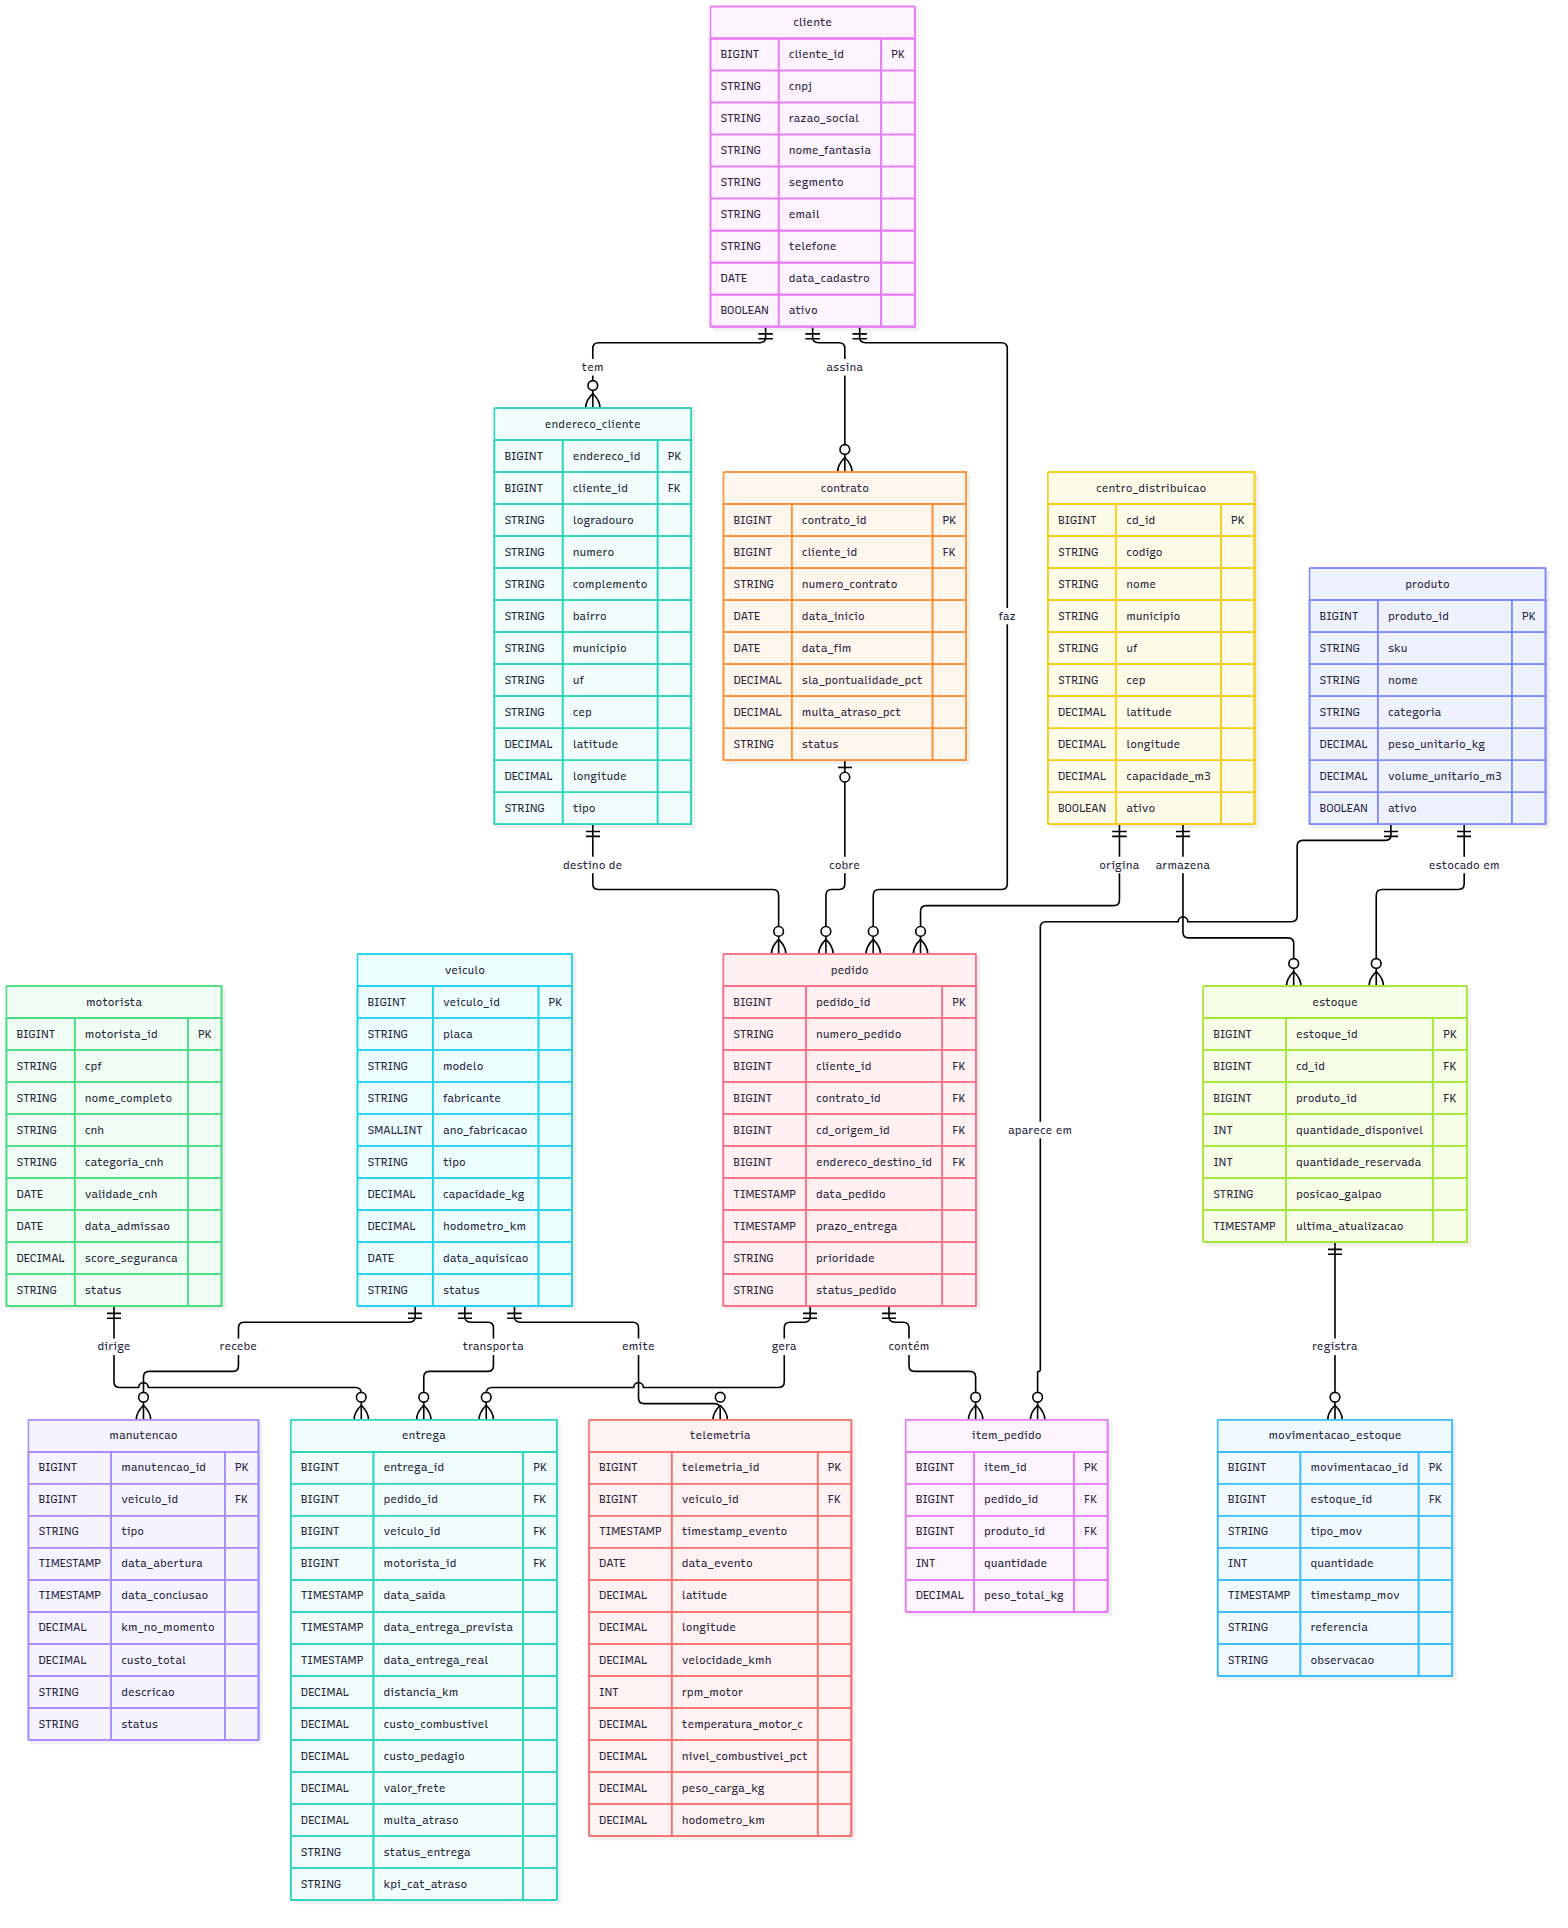

**Como ler o diagrama:** `||` = exatamente um; `o{` = zero ou muitos; `|o` = zero ou um. Exemplo: `cliente ||--o{ pedido` = um cliente faz zero ou muitos pedidos; cada pedido é de exatamente um cliente.

**Consequência da 3FN:** a `entrega` não guarda o nome do cliente nem a placa do veículo. Para saber a razão social do cliente de uma entrega, é preciso passar pelo pedido (`entrega → pedido → cliente`). Rode a célula abaixo para ver o caminho.

In [ ]:
%sql
-- Razão social do cliente e placa do veículo de 10 entregas: 3 JOINs no modelo em 3FN
SELECT e.entrega_id, c.razao_social, v.placa, e.data_entrega_real, e.kpi_cat_atraso
FROM lodlog_op.entrega e
JOIN lodlog_op.pedido  p ON p.pedido_id  = e.pedido_id
JOIN lodlog_op.cliente c ON c.cliente_id = p.cliente_id
JOIN lodlog_op.veiculo v ON v.veiculo_id = e.veiculo_id
LIMIT 10;

### Atividade 1.1: Relacionamentos e Cardinalidade (grupo, 15 min)

Use o diagrama para preencher a tabela. Atenção: nem todo par abaixo tem relacionamento **direto** no modelo. Se o relacionamento for indireto, indique por qual entidade ele passa.

| Entidade A | Entidade B | Direto ou indireto (via qual tabela)? | Cardinalidade | Descrição do Relacionamento |
| --- | --- | --- | --- | --- |
| CLIENTE | PEDIDO |  |  |  |
| PEDIDO | ENTREGA |  |  |  |
| VEICULO | MOTORISTA |  |  |  |
| PRODUTO | CENTRO_DISTRIBUICAO |  |  |  |
| MOTORISTA | MANUTENCAO |  |  |  |

**Discuta:** se o cliente 15 mudar de razão social, quantas linhas precisam ser alteradas neste modelo? E se a razão social estivesse repetida em cada entrega?

## Parte 2 — Star Schema e Perguntas de Negócio (35 min)

O diagrama abaixo é o Star Schema do schema analítico `lodlog_dw`. A `fato_entregas` tem **1 linha por entrega** e se liga a 6 dimensões por surrogate keys (`sk_*`).

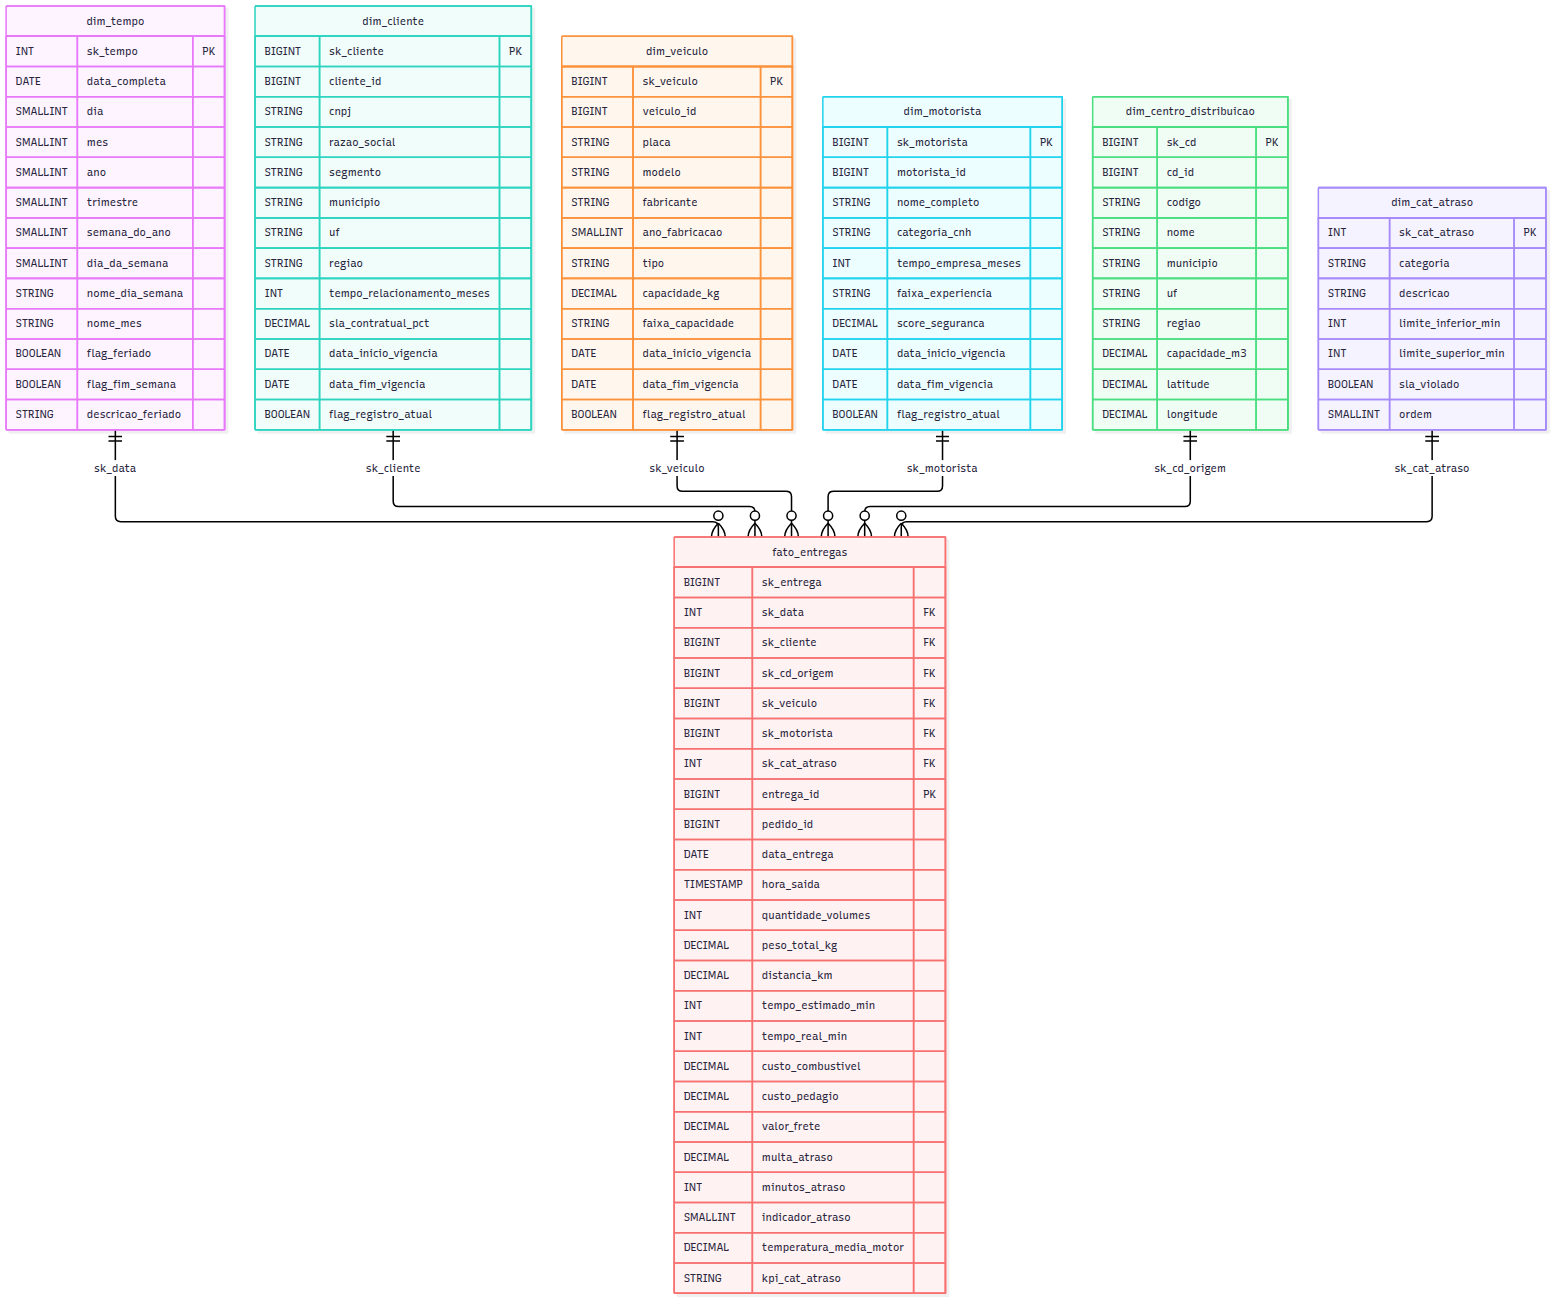

| Tabela | O que guarda |
| --- | --- |
| `fato_entregas` | Medidas da entrega: custos, frete, multa, distância, tempos, `minutos_atraso`, `indicador_atraso` (0 = pontual, 1 = atrasada) |
| `dim_tempo` | Calendário: dia, mês, trimestre, ano, dia da semana, feriado, fim de semana |
| `dim_cliente` | Cliente: razão social, segmento, município/UF/região, SLA contratual |
| `dim_veiculo` | Veículo: placa, modelo, tipo, faixa de capacidade |
| `dim_motorista` | Motorista: categoria da CNH, tempo de empresa, faixa de experiência, score de segurança |
| `dim_centro_distribuicao` | CD de origem: código, nome, município/UF/região |
| `dim_cat_atraso` | Mini-dimensão do KPI: Adiantado / No Prazo / Atraso Leve / Moderado / Crítico |

### Atividade 2.1: O modelo responde? (grupo, 25 min)

A diretoria da LODLog mandou as perguntas abaixo. Para cada uma, decida **se ela pode ser respondida com o Star Schema atual**. Não precisa escrever SQL.

* Se **pode**: indique a tabela fato, as dimensões e as colunas que seriam usadas.
* Se **não pode**: indique qual dado falta e de onde ele poderia vir.

> **Atenção:** nem todas as perguntas podem ser respondidas com o modelo atual.

1. Qual a taxa de pontualidade de cada centro de distribuição, mês a mês?
2. Qual o custo médio de frete por região e por tipo de veículo?
3. Nos dias de greve, bloqueio de rodovia ou acidente na cidade do CD, a taxa de atraso das entregas sobe?
4. Quais clientes tiveram mais entregas com **Atraso Crítico** no último trimestre?
5. Motoristas com score de segurança mais baixo atrasam mais?

| # | Possível? (Sim/Não) | Fato e dimensões | Colunas usadas | Se não for possível: que dado falta e de onde viria? |
| --- | --- | --- | --- | --- |
| 1 |  |  |  |  |
| 2 |  |  |  |  |
| 3 |  |  |  |  |
| 4 |  |  |  |  |
| 5 |  |  |  |  |

**Discuta:** escolha uma das perguntas possíveis. Quantas tabelas você precisaria juntar para respondê-la no modelo ER da Parte 1? E no Star Schema?

---

**— linha de base —** Daqui para baixo é desejável/opcional.

### Atividade 2.2: Diferença ER vs Star Schema (individual, 5 min)

| Característica | Modelo ER (Transacional) | Star Schema (Analítico) |
| --- | --- | --- |
| Objetivo principal |  |  |
| Número de tabelas |  |  |
| Tipo de JOIN |  |  |
| Granularidade |  |  |
| Uso de surrogate keys |  |  |
| Otimizado para |  |  |

### Atividade 2.3: Surrogate Keys (individual, 5 min)

| Tabela | Usa surrogate key? | Por quê? |
| --- | --- | --- |
| Fato entregas |  |  |
| Dimensão Tempo |  |  |
| Dimensão Cliente |  |  |
| Dimensão Veículo |  |  |
| Dimensão Centro de Distribuição |  |  |
| Dimensão Categoria Atraso |  |  |

### Atividade 2.4: Mini-dimensão do KPI (grupo, 5 min)

O seed criou a mini-dimensão `lodlog_dw.dim_cat_atraso` com 5 registros. Responda:

1. **Por que** a categoria de atraso foi para uma **mini-dimensão** (e não para a `dim_tempo` ou `dim_motorista`)?
2. A coluna `kpi_cat_atraso` aparece **duas vezes** no modelo: na `entrega` (operacional) e na `fato_entregas` (DW). Isso é **redundância** aceitável? Justifique.
3. A coluna `sla_violado` na mini-dimensão é uma **flag booleana**. Ela poderia virar uma **dimensão separada** (SCD Tipo 1)?

> **Conceito-chave — Mini-dimensão (Kimball):** atributos de **baixa cardinalidade** que são **estáveis** (mudam raramente) e usados em filtros/agrupamentos de BI devem ser isolados em uma **mini-dimensão**, em vez de serem replicados como string na fato. Isso permite:
>
> * Performance: a fato é menor (INT em vez de STRING)
> * Flexibilidade: trocar a descrição da categoria sem alterar a fato
> * Conformidade: o valor da categoria passa a ser controlado pela dimensão

In [ ]:
%sql
SELECT * FROM lodlog_dw.dim_cat_atraso ORDER BY ordem;

## Parte 3 — Consultas no Star Schema (opcional, 15 min)

### Atividade 3.1: Conte as entregas por categoria de atraso

Faça uma query que conte quantas entregas há em cada categoria (JOIN de `fato_entregas` com `dim_cat_atraso`).

In [ ]:
%sql
-- Entregas por categoria de atraso

### Atividade 3.2: Responda uma pergunta da Atividade 2.1

Escreva a consulta da pergunta 1 (taxa de pontualidade por CD e mês). Use como ponto de partida:

In [ ]:
%sql
SELECT cd.nome AS cd, t.ano, t.mes,
       SUM(CASE WHEN f.indicador_atraso = 0 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS taxa_pontualidade
-- complete com FROM, JOINs e GROUP BY

### Atividade 3.3: Justifique (grupo, 5 min)

1. Qual a granularidade da `fato_entregas`? Por que essa escolha permite responder às perguntas da Atividade 2.1?
2. Qual dimensão vai crescer mais? Como lidaria com isso?
3. Se o negócio pedir uma nova categoria "Atraso Severíssimo" (> 24h), o que muda no modelo?

---

**Dica do Professor:** O Star Schema não é "melhor" que o ER — são modelos para propósitos diferentes. O ER serve para operar (transações); o Star Schema serve para analisar (agregações). Um pipeline de dados bem projetado começa no ER dos sistemas transacionais (em 3FN) e termina no Star Schema do DW — com mini-dimensões para KPIs de baixa cardinalidade. E quando a pergunta exige um dado que nenhum sistema interno tem, é hora de buscar uma **nova fonte** (veremos isso no LAB 4).